<a href="https://colab.research.google.com/github/KarenKhou/SmartCloset/blob/main/MachineLearning/DetectionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Sun Apr 13 13:51:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.1/112.6 GB disk)


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 922, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.11/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are frozenset({'train', 'track', 'val', 'predict', 'export', 'benchmark'}).

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of frozenset({'pose', 'classify', 'detect', 'obb', 'segment'})
                MODE (required) is one of frozenset({'train', 'track', 'val', 'predict', 'export', 'benchmark'})
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' tha

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AMVUobZbQn01XSn2xIwB")
project = rf.workspace("dataset-yn4f8").project("main-fashion")
version = project.version(5)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Main-Fashion-5 in yolov8:: 100%|██████████| 5688/5688 [00:00<00:00, 8856.48it/s]


In [ ]:
!ls /content/


Main-Fashion-5


In [ ]:
!ls /content/Main-Fashion-5/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!cat /content/Main-Fashion-5/data.yaml


names:
- Tshirt
- dress
- jacket
- pants
- shirt
- short
- skirt
- sweater
nc: 8
roboflow:
  license: MIT
  project: main-fashion
  url: https://universe.roboflow.com/dataset-yn4f8/main-fashion/dataset/5
  version: 5
  workspace: dataset-yn4f8
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should be > 0

True
1


In [ ]:
dataset = version.download("yolov8")
print(dataset.location)

/content/Main-Fashion-5


In [ ]:
!rm -rf /content/runs/

In [ ]:
!yolo task=detect mode=train model=yolov8x.pt data="/content/Main-Fashion-5/data.yaml" epochs=50 imgsz=640  batch=16 amp=True lr0=0.01 lrf=0.1 momentum=0.937 weight_decay=0.0005

100% 131M/131M [00:00<00:00, 164MB/s]
Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/Main-Fashion-5/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True,

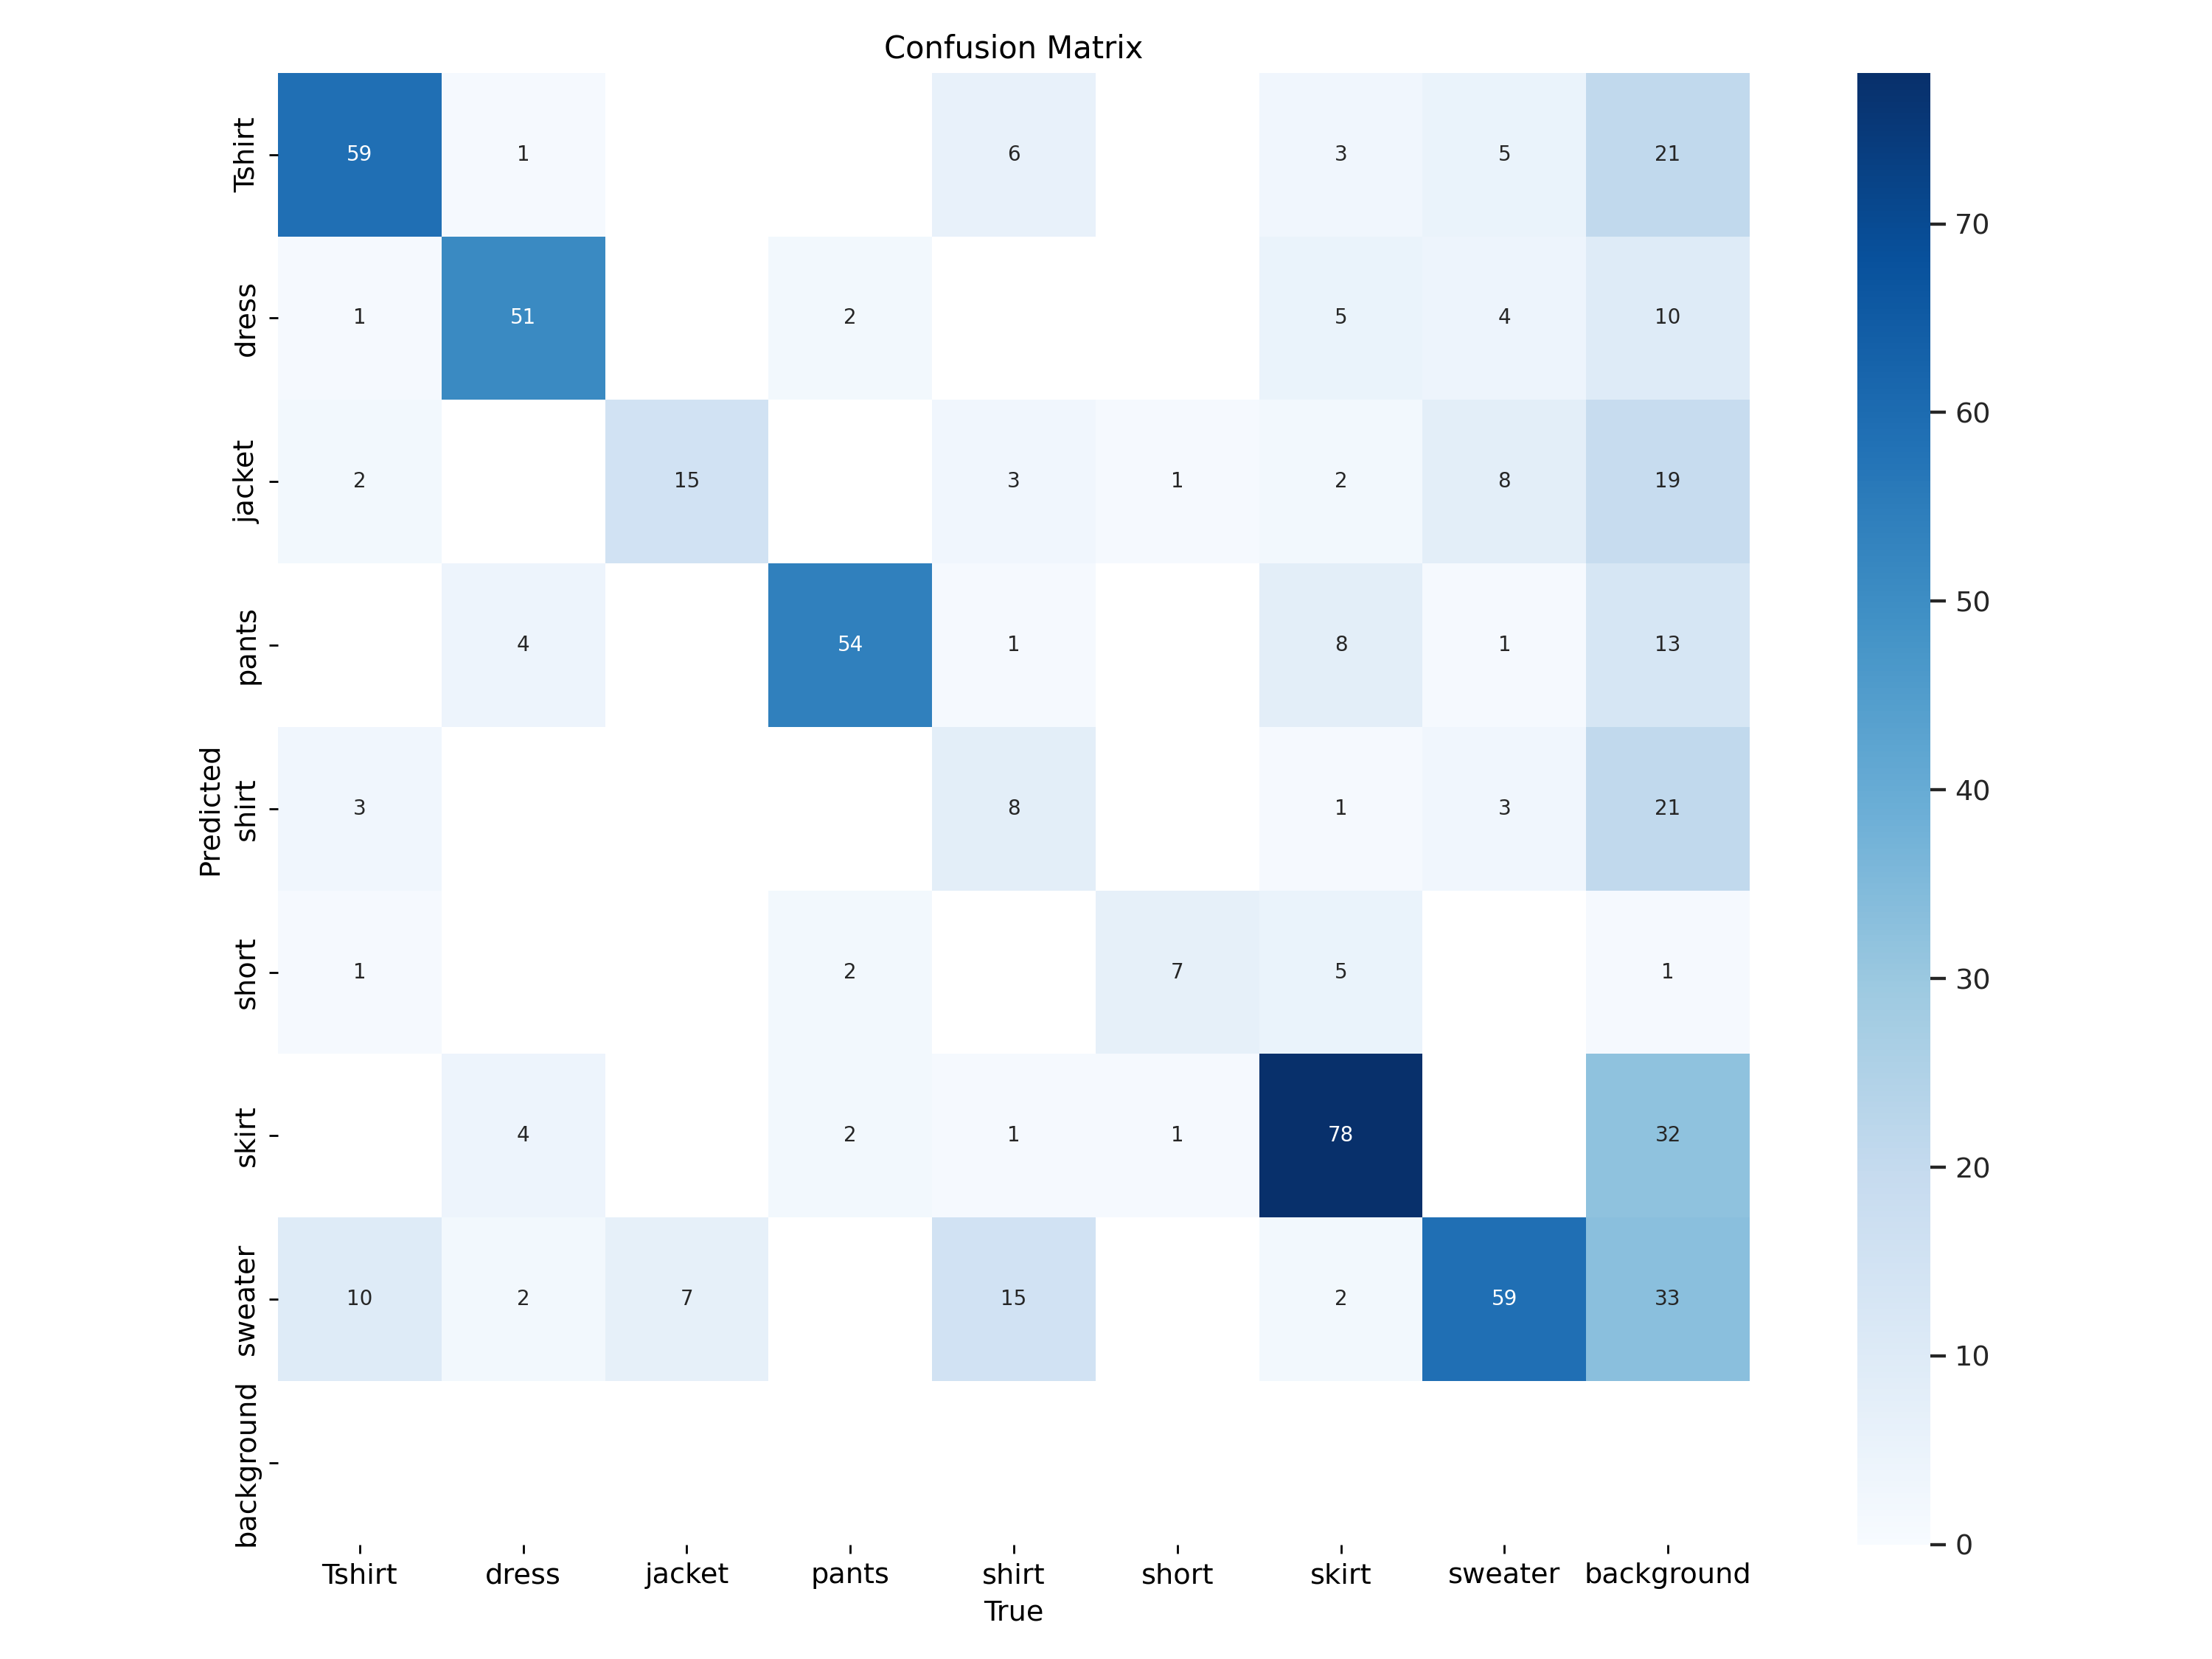

In [ ]:
from IPython.display import Image
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=900)

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data="/content/Main-Fashion-5/data.yaml"


Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 68,131,272 parameters, 0 gradients, 257.4 GFLOPs
val: Scanning /content/Main-Fashion-5/valid/labels.cache... 447 images, 0 backgrounds, 0 corrupt: 100% 447/447 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 447. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 28/28 [00:25<00:00,  1.08it/s]
                   all        447        447      0.752      0.775      0.841      0.841
                Tshirt         76         76      0.816      0.759      0.896      0.896
                 dress         62         62      0.913      0.903      0.962      0.962
                jacket         22         

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source="/content/Main-Fashion-5/test/images"

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 68,131,272 parameters, 0 gradients, 257.4 GFLOPs

image 1/238 /content/Main-Fashion-5/test/images/045e20b0592d4fb61d5a5f4b8a8ba6bf_jpg.rf.4810e78f33d8c3dc8e5c79c80f3747c9.jpg: 640x480 1 sweater, 84.9ms
image 2/238 /content/Main-Fashion-5/test/images/1588753551723_7169ryxt2v4_png_jpg.rf.302b3fe2631592c80f3c5f17bcc0b742.jpg: 640x576 1 Tshirt, 79.9ms
image 3/238 /content/Main-Fashion-5/test/images/1590122676583_omcucvx5g5o_jpg.rf.1c08eaf8d91e1b15f2e0bb6031b6512e.jpg: 640x416 1 Tshirt, 61.4ms
image 4/238 /content/Main-Fashion-5/test/images/1590122676583_omcucvx5g5o_jpg.rf.5fef7c3ee884ef405338fe22d466694b.jpg: 640x384 1 Tshirt, 55.2ms
image 5/238 /content/Main-Fashion-5/test/images/1605496729823_ci0o5aow9x_jpg.rf.35e4899435f28df4b5a044f4e3b06fb1.jpg: 640x640 1 Tshirt, 59.7ms
image 6/238 /content/Main-Fashion-5/test/images/1607488651407_d2wyq3yi4z5_jpg.rf.a4da67fb51eb50d28efb

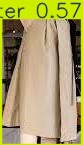

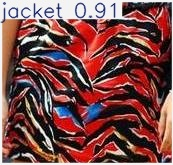

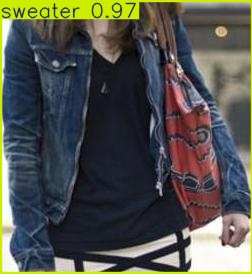

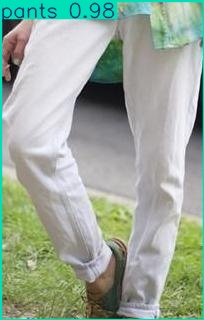

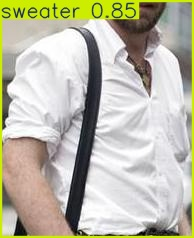

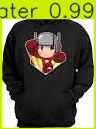

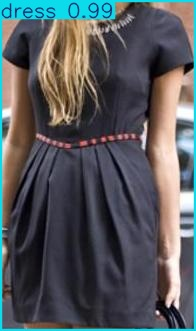

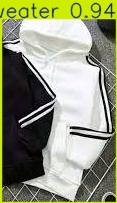

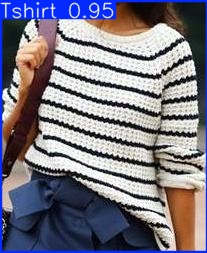

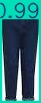

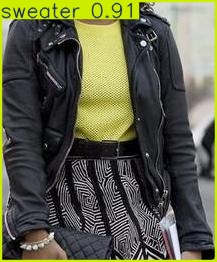

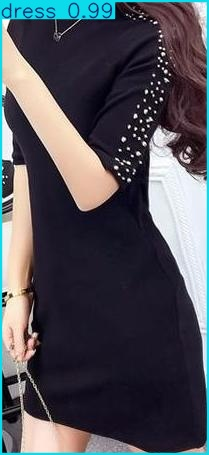

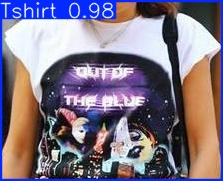

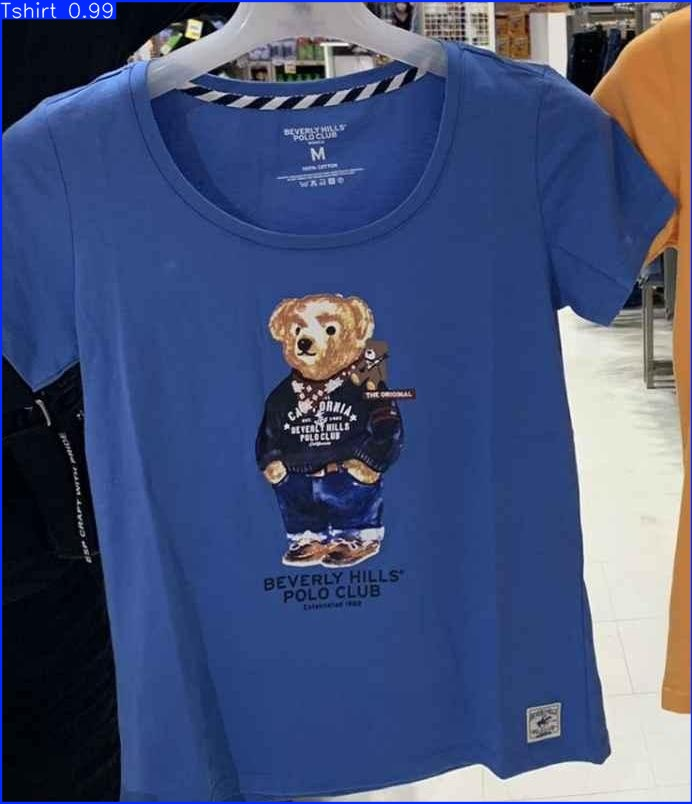

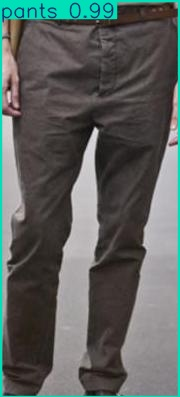

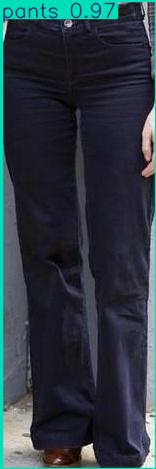

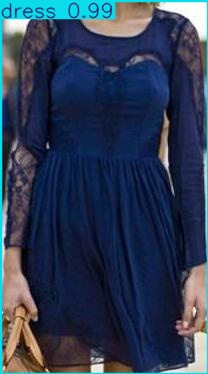

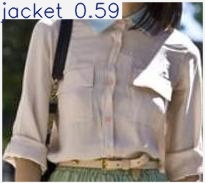

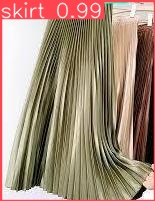

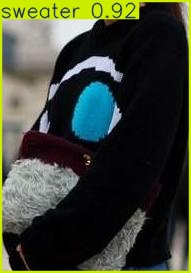

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:20]:
  display(Image(filename=image_path,height=600))
  print("\n")